In [1]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
# Load merged subject
mat = sio.loadmat("data/merge/S1_merge.mat")

emg = mat["emg"]              # Shape: (samples, 16)
stimulus = mat["stimulus"].flatten()

print("EMG shape      :", emg.shape)
print("Stimulus shape :", stimulus.shape)

EMG shape      : (568540, 16)
Stimulus shape : (568540,)


In [3]:
# Create DataFrame for presentation
columns = [f"CH{i+1}" for i in range(16)]

df = pd.DataFrame(emg, columns=columns)
df["Stimulus"] = stimulus

print("===== FIRST 10 DATA =====")
display(df.head(10))

print("===== LAST 10 DATA =====")
display(df.tail(10))

===== FIRST 10 DATA =====


,CH1,CH2,CH3,CH4,CH5,CH6,CH7,CH8,CH9,CH10,CH11,CH12,CH13,CH14,CH15,CH16,Stimulus
0,-22.0,-2.0,-16.0,-7.0,-3.0,-1.0,-2.0,-4.0,-2.0,-46.0,-49.0,-5.0,9.0,1.0,-1.0,-2.0,0
1,5.0,-4.0,-12.0,-3.0,8.0,25.0,1.0,1.0,-2.0,66.0,28.0,3.0,22.0,10.0,2.0,1.0,0
2,-6.0,1.0,4.0,-1.0,-9.0,0.0,-10.0,-3.0,-9.0,-52.0,-24.0,-2.0,-52.0,-14.0,-24.0,-3.0,0
3,15.0,10.0,19.0,9.0,10.0,7.0,2.0,1.0,-4.0,-13.0,19.0,4.0,28.0,6.0,-5.0,-12.0,0
4,-1.0,-16.0,-17.0,0.0,-2.0,-7.0,2.0,0.0,-6.0,27.0,7.0,-1.0,-22.0,-2.0,-7.0,15.0,0
5,2.0,-4.0,-5.0,-7.0,-1.0,17.0,6.0,-5.0,13.0,-8.0,-34.0,-6.0,12.0,1.0,7.0,-20.0,0
6,-4.0,2.0,-23.0,-1.0,-2.0,5.0,-8.0,-6.0,-14.0,-11.0,-24.0,-7.0,-3.0,6.0,-3.0,4.0,0
7,-18.0,-9.0,1.0,-4.0,0.0,-4.0,3.0,-8.0,-41.0,-1.0,-7.0,3.0,7.0,-1.0,4.0,-1.0,0
8,18.0,48.0,-2.0,-2.0,-4.0,-2.0,-7.0,-1.0,-5.0,16.0,-7.0,-5.0,-1.0,-4.0,-1.0,-6.0,0
9,-3.0,-34.0,-32.0,-1.0,-4.0,-4.0,2.0,2.0,3.0,-13.0,7.0,5.0,-3.0,1.0,-12.0,5.0,0


===== LAST 10 DATA =====


,CH1,CH2,CH3,CH4,CH5,CH6,CH7,CH8,CH9,CH10,CH11,CH12,CH13,CH14,CH15,CH16,Stimulus
568530,-8.0,-1.0,0.0,-2.0,-1.0,-2.0,-1.0,-3.0,16.0,-20.0,0.0,3.0,6.0,2.0,-1.0,-2.0,52
568531,-1.0,-3.0,-6.0,-3.0,-2.0,-1.0,1.0,16.0,-5.0,15.0,-2.0,2.0,8.0,0.0,0.0,0.0,52
568532,-1.0,-4.0,0.0,0.0,-2.0,-1.0,0.0,-2.0,28.0,0.0,2.0,-8.0,-32.0,-4.0,0.0,2.0,52
568533,5.0,2.0,-1.0,0.0,0.0,-1.0,-1.0,-4.0,-7.0,-10.0,-2.0,-2.0,2.0,1.0,2.0,3.0,52
568534,-6.0,-3.0,0.0,1.0,0.0,0.0,0.0,-6.0,-103.0,-21.0,-9.0,-5.0,-6.0,-3.0,-5.0,-8.0,52
568535,-14.0,2.0,0.0,0.0,0.0,0.0,-1.0,2.0,63.0,27.0,3.0,1.0,6.0,-4.0,-2.0,0.0,52
568536,-1.0,-3.0,-2.0,-2.0,0.0,-4.0,-2.0,-4.0,-26.0,-20.0,1.0,6.0,13.0,2.0,1.0,1.0,52
568537,5.0,-3.0,2.0,-2.0,-1.0,-1.0,-4.0,-16.0,-1.0,-2.0,0.0,3.0,-4.0,-3.0,-6.0,-6.0,52
568538,-3.0,-1.0,-2.0,-3.0,-2.0,1.0,2.0,9.0,7.0,13.0,2.0,-1.0,-3.0,1.0,3.0,5.0,52
568539,-8.0,4.0,-4.0,-1.0,-1.0,-2.0,1.0,7.0,-5.0,-46.0,-3.0,-5.0,-7.0,-3.0,-5.0,-8.0,52


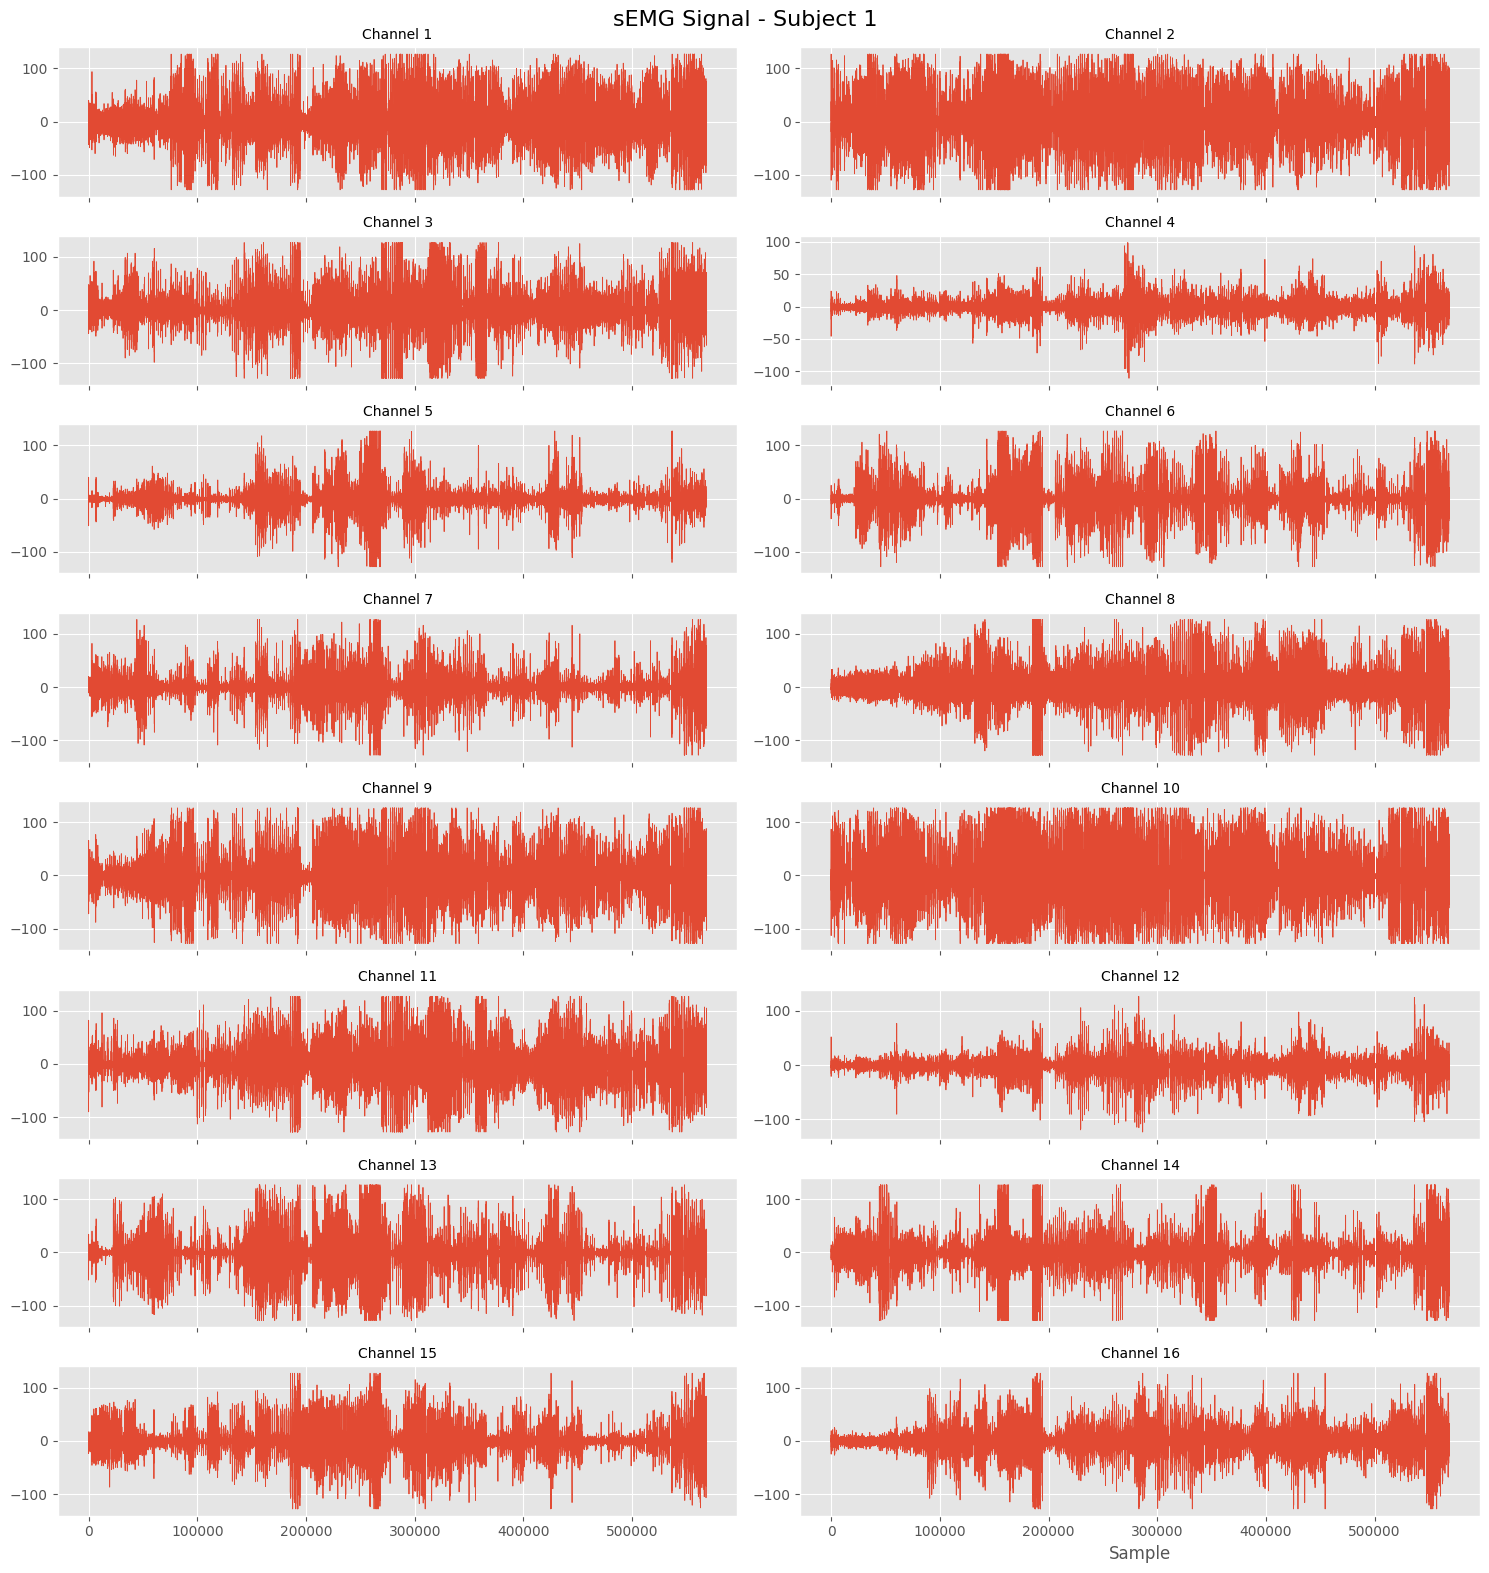

In [4]:
fig, axes = plt.subplots(8, 2, figsize=(15, 16), sharex=True)

for ch in range(16):
    ax = axes[ch // 2, ch % 2]
    ax.plot(emg[:, ch], linewidth=0.6)
    ax.set_title(f"Channel {ch+1}", fontsize=10)

plt.suptitle("sEMG Signal - Subject 1", fontsize=16)
plt.xlabel("Sample")
plt.tight_layout()
plt.show()

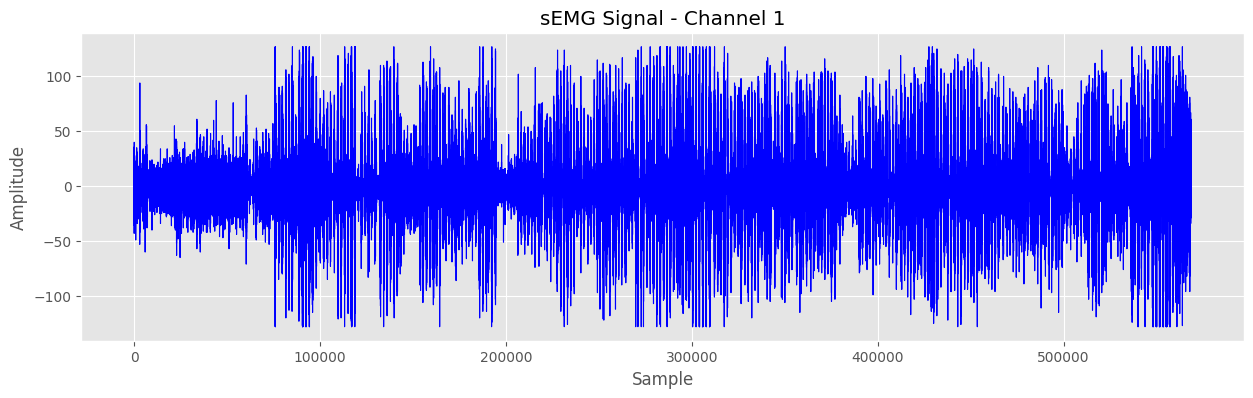

In [5]:
plt.figure(figsize=(15,4))
plt.plot(emg[:,0], color="blue", linewidth=0.8)

plt.title("sEMG Signal - Channel 1")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [6]:
print("========== DATA SUMMARY ==========")
print(f"Total samples  : {len(stimulus):,}")
print(f"EMG channels   : {emg.shape[1]}")
print(f"Number of classes : {len(np.unique(stimulus)) - 1}")  # exclude 0

# Count each stimulus
class_count = (
    pd.Series(stimulus)
      .value_counts()
      .sort_index()
      .rename_axis("Class")
      .reset_index(name="Samples")
)

display(class_count)

========== DATA SUMMARY ==========
Total samples  : 568,540
EMG channels   : 16
Number of classes : 52


,Class,Samples
0,0,219439
1,1,6753
2,2,6656
3,3,6613
4,4,6654
5,5,6782
6,6,6776
7,7,6776
8,8,6795
9,9,6626


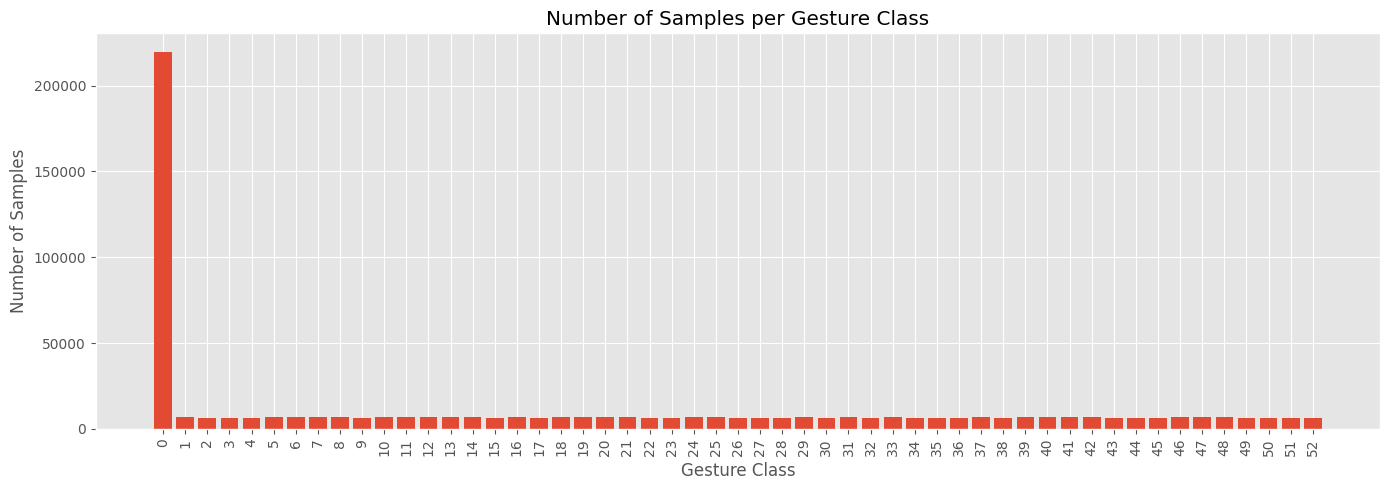

In [7]:
plt.figure(figsize=(14,5))

plt.bar(class_count["Class"].astype(str),
        class_count["Samples"])

plt.title("Number of Samples per Gesture Class")
plt.xlabel("Gesture Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()